# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


PyTorch version: 2.12.0+cpu
CUDA available: False


In [3]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc15'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
DATA_LIMIT = 10000
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350

# First-pass anti-saturation knobs: keep capacity fixed, increase score signal.
EMBEDDING_DIM = 64
LEARNING_RATE = 2e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.5

# Capacity knobs. Increase only after the dense-signal run still plateaus.
NUMBER_OF_TRANSFORMER_LAYERS = 3
TRANSFORMER_ATTENTION_HEAD_COUNT = 4
TRANSFORMER_DROPOUT = 0.1

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

MODEL_NAME = (
    f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-s{DATA_LIMIT}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [4]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}


ZINC CSV: /run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/notebooks/datasets/zinc/zinc15.csv
Loaded 10000 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc15-nonstreaming-d64-s10000-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators


Fit target model_name=zinc15-nonstreaming-d64-s10000-b128-e350 model_dir=/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 10000 graphs
Fitted node embedding SVD: 2048 -> 64.
Fitted graph embedding SVD: 2048 -> 64.
Fitting feasibility estimator on 10000 graphs
Finished fitting feasibility estimator in 1m 39.6s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=learned, enabled, horizon=2. Use horizon-2 locality as auxiliary regularization.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 844046 pairs (50.00%) from 1688092 total pairs (pos=563376, neg=1124716, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[dir

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/fabrizio/.venvs/py314/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 10/350 | ETA 73h 30m 11s:
  train total=   55.135 | node_field    22.617 [41.0%] |        deg    3.2391 [5.9%] |      exist   0.13968 [0.3%] | node_count   0.00190 [<0.1%]
  val   total=   54.198 | node_field    22.517 [41.5%] |        deg    3.0555 [5.6%] |      exist   0.13313 [0.2%] | node_count   0.00190 [<0.1%]
  train                 | node_label    1.4812 [2.7%] | edge_label    1.4145 [2.6%] |       edge    2.6958 [4.9%] | edge_count    21.964 [39.8%] | deg_edge_consistency   0.00049 [<0.1%]
  val                   | node_label    1.3075 [2.4%] | edge_label    1.2788 [2.4%] |       edge    2.6617 [4.9%] | edge_count    21.674 [40.0%] | deg_edge_consistency   0.00045 [<0.1%]
  train                 |        aux    1.5822 [2.9%] | dominant=node_field [41.0%]
  val                   |        aux    1.5680 [2.9%] | dominant=node_field [41.5%]
Epoch 20/350 | ETA 66h 20m 04s:
  train total=   53.352 | node_field    22.463 [42.1%] |        deg    2.9266 [5.5%] |      exist   0.13

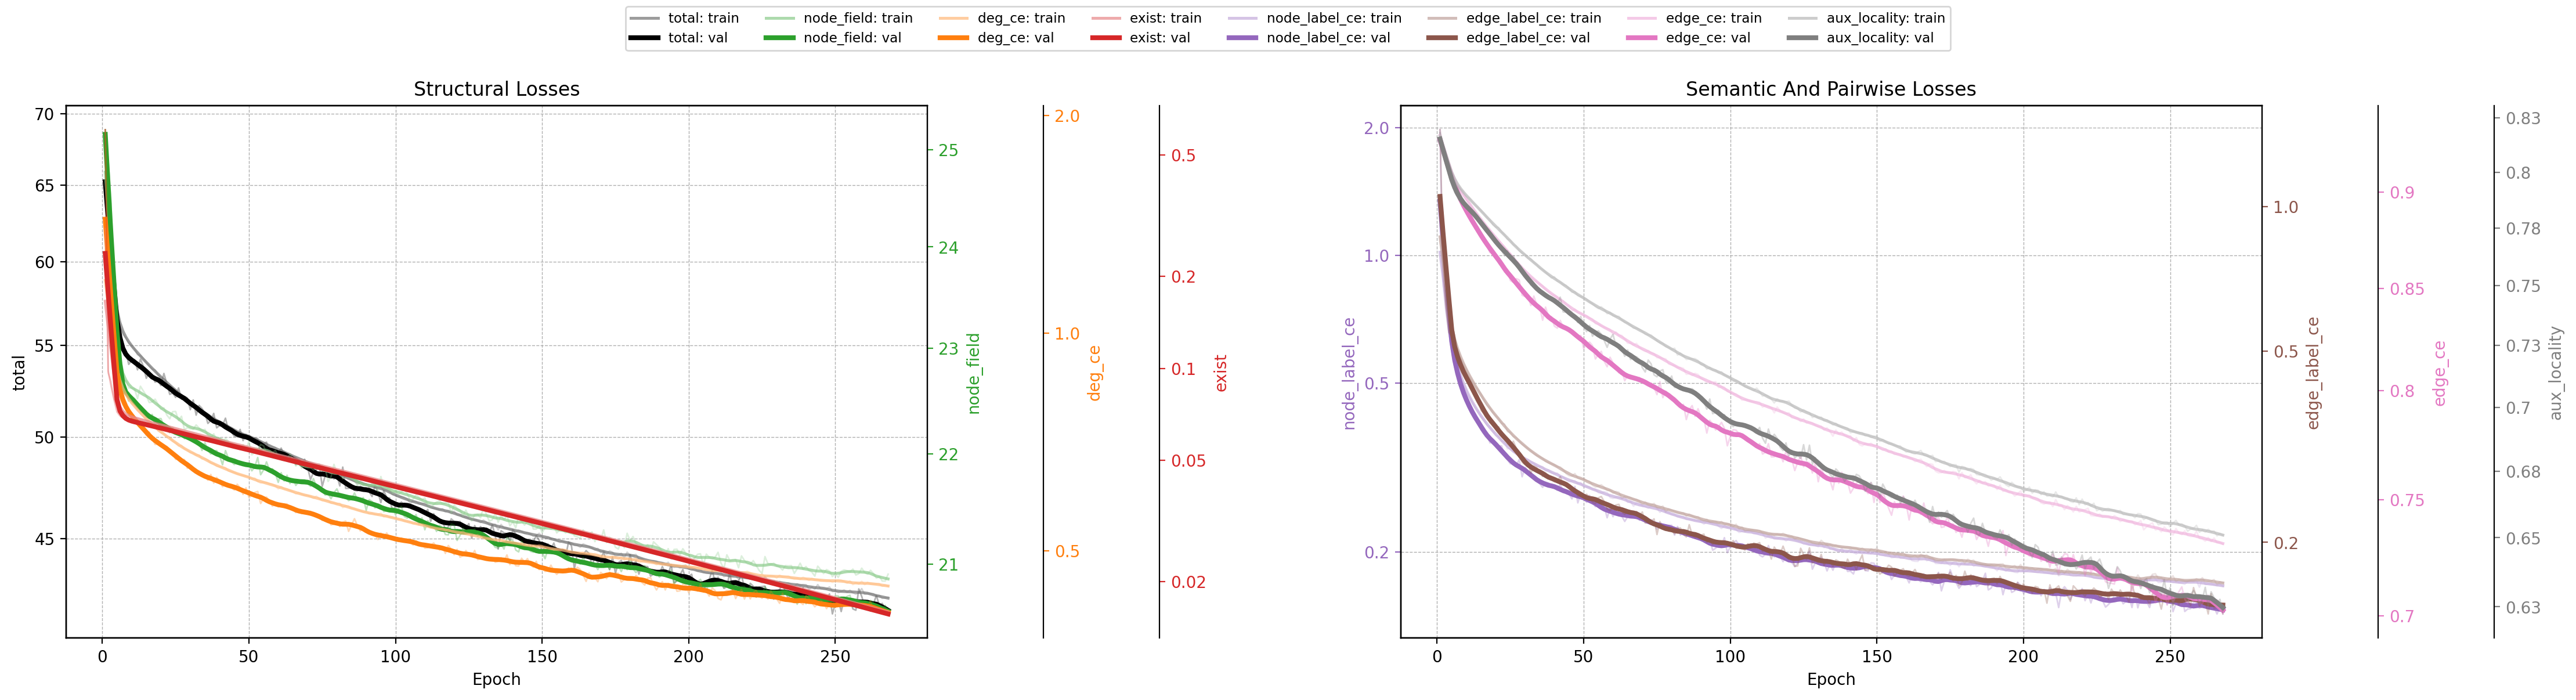

training_graph_conditioning_ = 10000
is_fitted_ = True


In [4]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=10,
    sample_training_progress_plot_kwargs=TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS,
    sample_training_progress_plot_fn=draw_molecule,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [5]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc20-nonstreaming-d64-s0-99-b128-e350.pkl'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)

,name,modified,size_mb
0,zinc15-nonstreaming-d64-s10000-b128-e350.pkl,2026-05-29 22:10,10.4
1,artificial-cycle-path-star-n5000-c6-p4-r3x2-d6...,2026-05-29 22:03,7.9


Loaded graph generator: zinc15-nonstreaming-d64-s10000-b128-e350.pkl
/run/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators/zinc15-nonstreaming-d64-s10000-b128-e350.pkl


Non-streaming ZINC raw samples


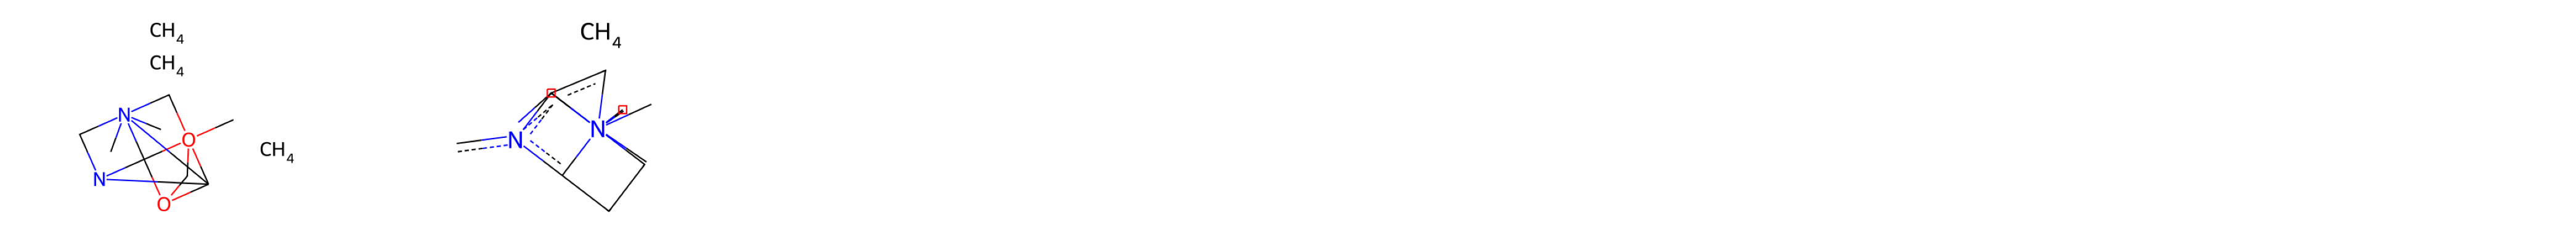

Non-streaming ZINC ILP samples


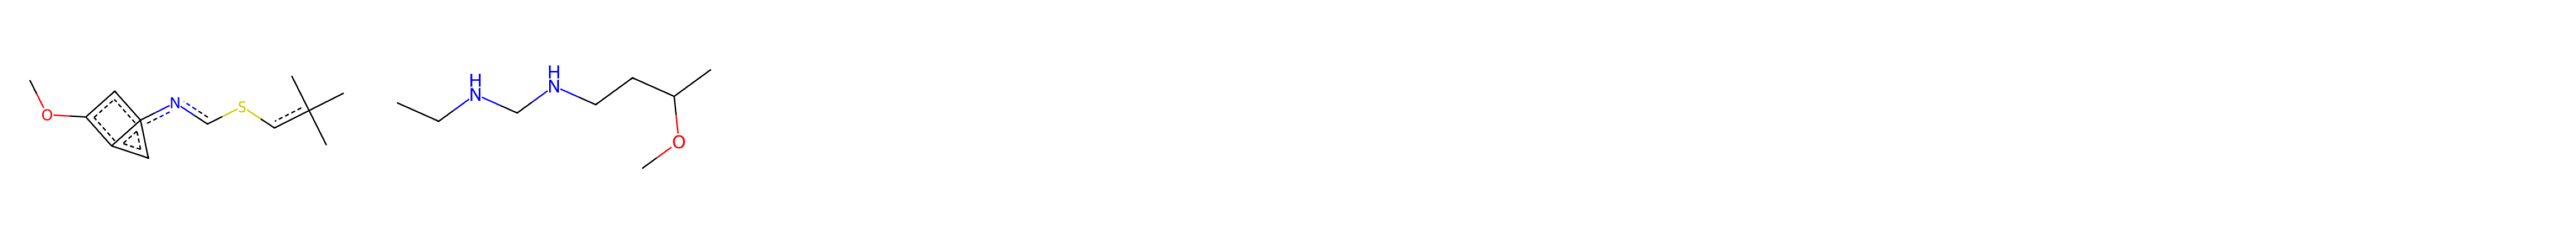

In [6]:
n_samples = 3
raw_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=False,
)
show_molecules(raw_samples, n=n_samples, title='Non-streaming ZINC raw samples')

ilp_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
)
show_molecules(ilp_samples, n=n_samples, title='Non-streaming ZINC ILP samples')

oracle_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
    use_feasibility_oracle=True,
)
show_molecules(oracle_samples, n=n_samples, title='Non-streaming ZINC Oracle samples')


Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 8 | feasible_rate=100.0% | attempt_time=   59.9s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=8, feasible_rate=100.0%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 8 | feasible_rate=100.0% | attempt_time=3m 49.3s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=8, feasible_rate=100.0%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 5 | feasible_rate= 62.5% | attempt_time=4m 04.2s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=5, feasible_rate=62.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 7 | feasible_rate= 87.5% | attempt_time=4m 07.1s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=7, feasible_rate=87.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8

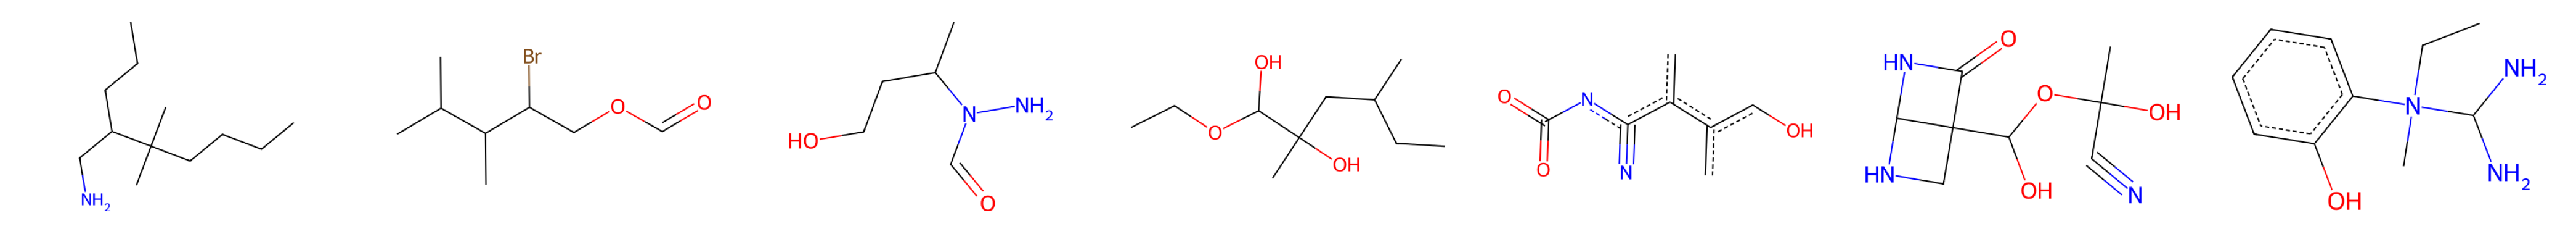

In [7]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=n_samples, title='Non-streaming ZINC samples with feasibility filtering')
